In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Crippen, rdMolDescriptors

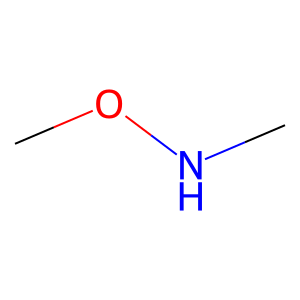

In [12]:
#RDKIT test
mol = Chem.MolFromSmiles("CONC")
Draw.MolToImage(mol)

In [13]:
#Read data
all_data = pd.read_csv('data/esol.csv')
all_data = all_data[['Compound ID','measured log solubility in mols per litre','smiles']]
all_data

,Compound ID,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-3.300,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.060,CC(C)=CCCC(C)=CC(=O)
3,Picene,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-1.330,c1ccsc1
...,...,...,...
1123,halothane,-1.710,FC(F)(F)C(Cl)Br
1124,Oxamyl,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C
1125,Thiometon,-3.091,CCSCCSP(=S)(OC)OC
1126,2-Methylbutane,-3.180,CCC(C)C


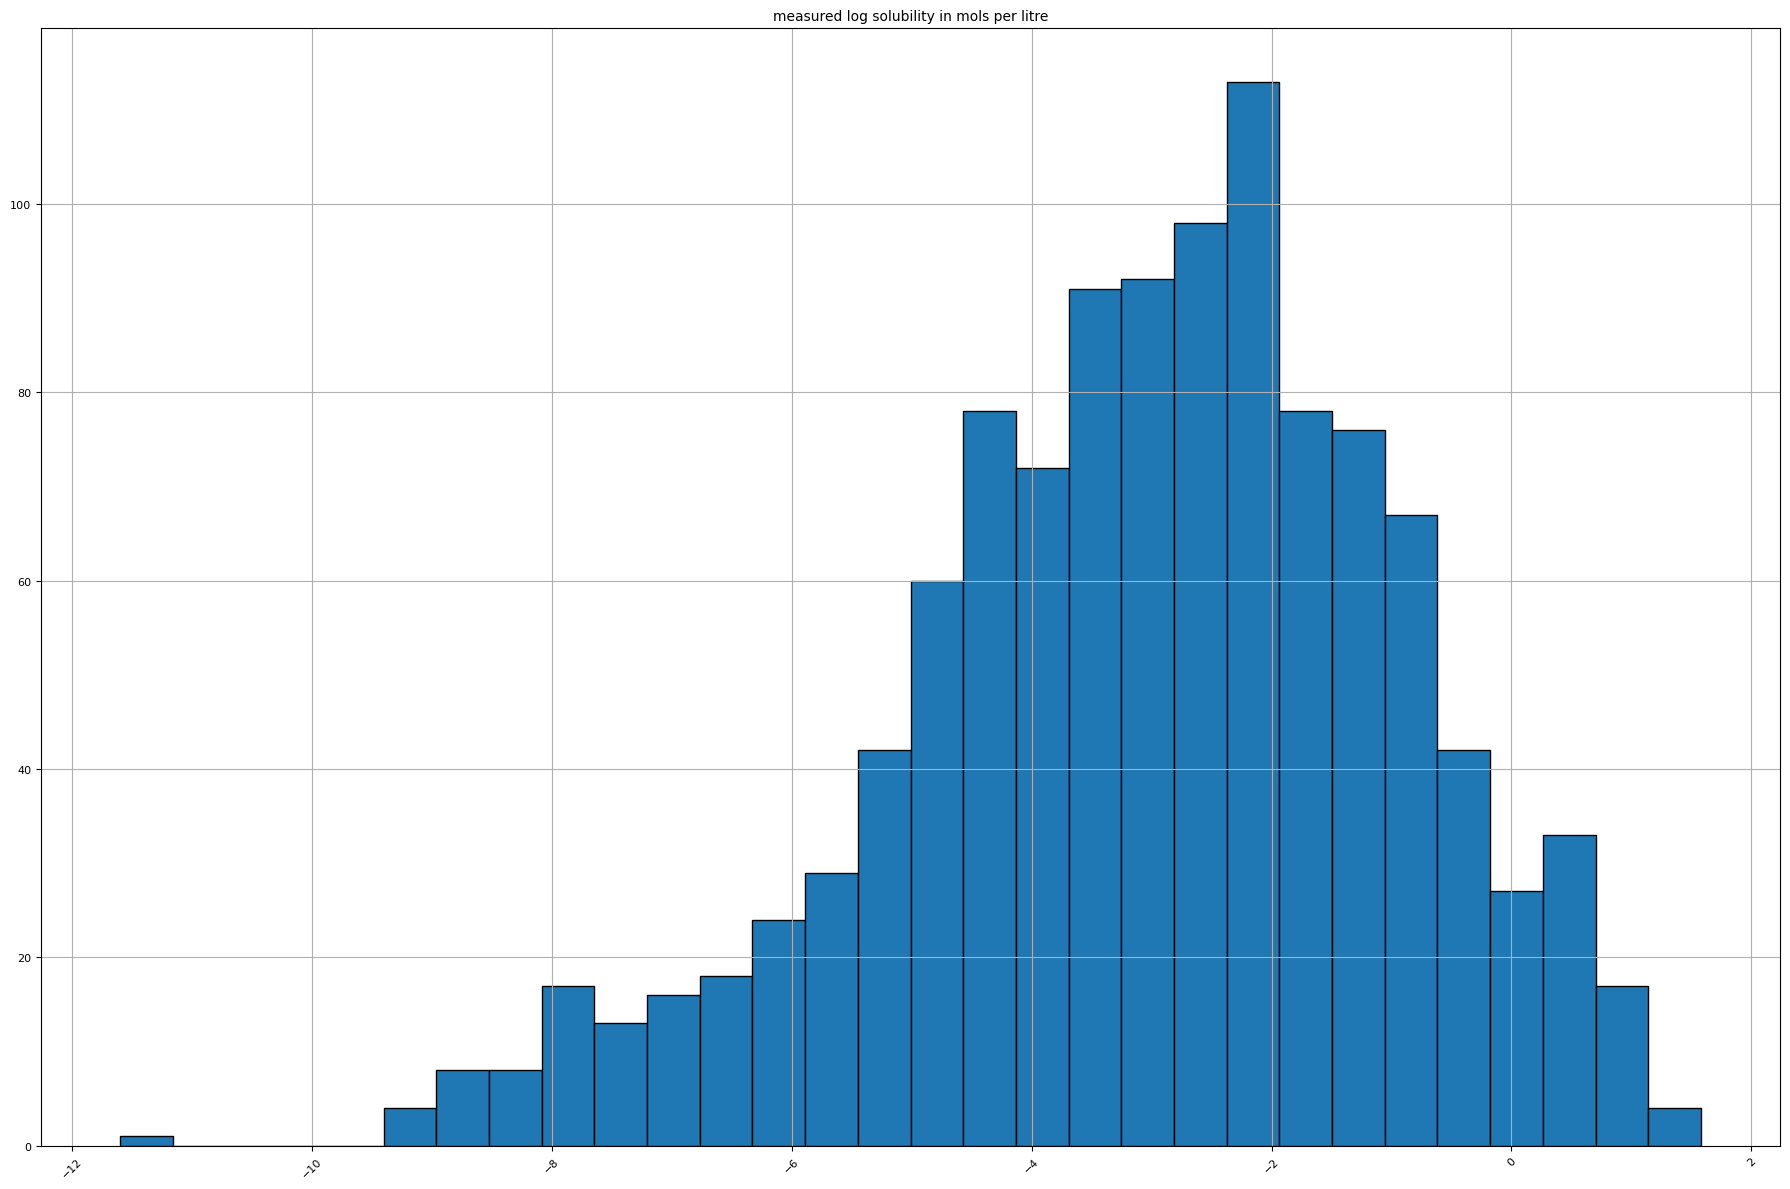

In [14]:
#Information get
axes = all_data.hist(
    figsize=(18, 12),
    bins=30,
    edgecolor="black",
    xrot=45
 )

for ax in np.ravel(axes):
    ax.set_title(ax.get_title(), fontsize=10)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

In [15]:
#Get all Descriptors
desc_names = [desc_name[0] for desc_name in Descriptors._descList]
desc_calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

#Calculation funtction
def get_descriptors(smile):
    """将 SMILES 转换为 RDKit 描述符向量"""
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    return desc_calc.CalcDescriptors(mol)

compound_id_desc = []
smiles_desc = []
descriptors_list = []
labels_desc = []

print("开始计算描述符...")
for i, row in all_data.iterrows():
    compound_id = row['Compound ID']
    smile = row['smiles']
    label = row['measured log solubility in mols per litre']
    
    desc = get_descriptors(smile)
    
    if desc is not None:
        compound_id_desc.append(compound_id)
        smiles_desc.append(smile)
        descriptors_list.append(desc)
        labels_desc.append(label)

print(f"成功计算了 {len(descriptors_list)} 个分子的描述符。")

开始计算描述符...
成功计算了 1128 个分子的描述符。


In [ ]:
#Build descriptors DataFrame
desc_df = pd.DataFrame(descriptors_list, columns=desc_names)

meta_df = pd.DataFrame({
    'Compound ID': compound_id_desc,
    'smiles': smiles_desc,
    'measured log solubility in mols per litre': labels_desc
})

all_data_descriptors_df = pd.concat([meta_df, desc_df], axis=1)
all_data_descriptors_df.to_csv('data/comound_with_desc.csv')
all_data_descriptors_df

,Compound ID,smiles,measured log solubility in mols per litre,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,10.253329,10.253329,0.486602,-1.701605,0.217518,41.062500,457.432,...,0,0,0,0,0,0,0,0,0,0
1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.300,11.724911,11.724911,0.145880,-0.145880,0.811283,9.933333,201.225,...,0,0,0,0,0,0,0,0,0,0
2,citral,CC(C)=CCCC(C)=CC(=O),-2.060,10.020498,10.020498,0.845090,0.845090,0.343706,11.000000,152.237,...,0,0,0,0,0,0,0,0,0,0
3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870,2.270278,2.270278,1.301055,1.301055,0.291526,11.636364,278.354,...,0,0,0,0,0,0,0,0,0,0
4,Thiophene,c1ccsc1,-1.330,2.041667,2.041667,1.712963,1.712963,0.448927,8.000000,84.143,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,halothane,FC(F)(F)C(Cl)Br,-1.710,10.999421,10.999421,1.916667,-4.317901,0.523506,16.714286,197.381,...,0,0,0,0,0,0,0,0,0,0
1124,Oxamyl,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,11.337508,11.337508,0.123704,-0.705457,0.293876,10.714286,219.266,...,1,0,0,0,0,0,0,0,0,0
1125,Thiometon,CCSCCSP(=S)(OC)OC,-3.091,5.174287,5.174287,1.011373,-1.984662,0.506070,11.916667,246.359,...,1,0,0,0,0,0,0,0,0,0
1126,2-Methylbutane,CCC(C)C,-3.180,2.222222,2.222222,0.884259,0.884259,0.444441,9.600000,72.151,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#Compare linear and nonlinear relationships with solubility
from sklearn.feature_selection import mutual_info_regression

target_col = 'measured log solubility in mols per litre'
meta_cols = ['Compound ID', 'smiles', target_col]

# Keep only descriptor columns and convert to numeric
X = all_data_descriptors_df.drop(columns=meta_cols, errors='ignore').apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(all_data_descriptors_df[target_col], errors='coerce')

# Clean invalid values for robust statistics
X = X.replace([np.inf, -np.inf], np.nan)
valid_mask = y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Fill missing values with column median
X = X.fillna(X.median(numeric_only=True))

# Remove constant columns (no information)
non_constant_cols = X.columns[X.nunique(dropna=False) > 1]
X = X[non_constant_cols]

# 1) Linear relation: absolute Pearson correlation
pearson_abs = X.apply(lambda col: col.corr(y)).abs().fillna(0.0)
pearson_raw = X.apply(lambda col: col.corr(y)).fillna(0.0)

# 2) Nonlinear relation: Mutual Information
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns)

# Build comparison table
relation_df = pd.DataFrame({
    'descriptor': X.columns,
    'linear_abs_pearson': pearson_abs.reindex(X.columns).values,
    'linear_pearson': pearson_raw.reindex(X.columns).values,
    'nonlinear_mutual_info': mi_series.reindex(X.columns).values
})

# Ranking (higher is stronger)
linear_ranked = relation_df.sort_values('linear_abs_pearson', ascending=False).reset_index(drop=True)
nonlinear_ranked = relation_df.sort_values('nonlinear_mutual_info', ascending=False).reset_index(drop=True)

# Optional combined score for quick overall comparison
relation_df['linear_rank'] = relation_df['linear_abs_pearson'].rank(ascending=False, method='average')
relation_df['nonlinear_rank'] = relation_df['nonlinear_mutual_info'].rank(ascending=False, method='average')
relation_df['avg_rank'] = (relation_df['linear_rank'] + relation_df['nonlinear_rank']) / 2
combined_ranked = relation_df.sort_values('avg_rank', ascending=True).reset_index(drop=True)

print('Top 20 linear (Pearson abs):')
display(linear_ranked.head(20))

print('Top 20 nonlinear (Mutual Information):')
display(nonlinear_ranked.head(20))

print('Top 20 combined (average rank):')
display(combined_ranked.head(20))

Top 20 linear (Pearson abs):


,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info
0,MolLogP,0.827918,-0.827918,0.792878
1,PEOE_VSA6,0.704852,-0.704852,0.433297
2,MolMR,0.699756,-0.699756,0.500652
3,LabuteASA,0.655502,-0.655502,0.469273
4,Chi0v,0.654884,-0.654884,0.520071
5,MolWt,0.640189,-0.640189,0.467775
6,HeavyAtomMolWt,0.639511,-0.639511,0.500044
7,ExactMolWt,0.639112,-0.639112,0.458112
8,Chi1v,0.635888,-0.635888,0.541120
9,FpDensityMorgan1,0.600940,0.600940,0.249728


Top 20 nonlinear (Mutual Information):


,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info
0,MolLogP,0.827918,-0.827918,0.792878
1,Chi1v,0.635888,-0.635888,0.541120
2,Chi0v,0.654884,-0.654884,0.520071
3,MolMR,0.699756,-0.699756,0.500652
4,HeavyAtomMolWt,0.639511,-0.639511,0.500044
5,LabuteASA,0.655502,-0.655502,0.469273
6,MolWt,0.640189,-0.640189,0.467775
7,Chi3v,0.566111,-0.566111,0.466721
8,MaxAbsEStateIndex,0.077186,0.077186,0.464191
9,MaxEStateIndex,0.077186,0.077186,0.464028


Top 20 combined (average rank):


,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info,linear_rank,nonlinear_rank,avg_rank
0,MolLogP,0.827918,-0.827918,0.792878,1.0,1.0,1.0
1,MolMR,0.699756,-0.699756,0.500652,3.0,4.0,3.5
2,Chi0v,0.654884,-0.654884,0.520071,5.0,3.0,4.0
3,LabuteASA,0.655502,-0.655502,0.469273,4.0,6.0,5.0
4,Chi1v,0.635888,-0.635888,0.541120,9.0,2.0,5.5
5,HeavyAtomMolWt,0.639511,-0.639511,0.500044,7.0,5.0,6.0
6,MolWt,0.640189,-0.640189,0.467775,6.0,7.0,6.5
7,PEOE_VSA6,0.704852,-0.704852,0.433297,2.0,15.0,8.5
8,ExactMolWt,0.639112,-0.639112,0.458112,8.0,11.0,9.5
9,Chi3v,0.566111,-0.566111,0.466721,18.0,8.0,13.0


In [18]:
#Save descriptors
linear_ranked.to_csv('data/descriptor.csv')

In [21]:
#GNN features
import pickle
import numpy as np

def export_for_gnn(smiles_list, y_labels, filename='data/gnn_data.pkl'):
    temp_data = []
    all_nodes = []
    
    for smiles, y in zip(smiles_list, y_labels):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        
        # 1. 提取原子特征
        nodes = [[a.GetAtomicNum(), a.GetTotalDegree(), int(a.GetIsAromatic())] 
                 for a in mol.GetAtoms()]
        all_nodes.extend(nodes)
        
        # 2. 提取边索引
        edges = []
        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edges.extend([[start, end], [end, start]])
            
        # 暂存数据
        temp_data.append({
            'nodes': nodes,
            'edge_index': edges,
            'y': float(y)
        })
        
    # === 计算全局 Max-Min 归一化参数 ===
    all_nodes_np = np.array(all_nodes, dtype=np.float32)
    x_min = all_nodes_np.min(axis=0)
    x_max = all_nodes_np.max(axis=0)
    range_val = x_max - x_min
    range_val[range_val == 0] = 1.0  # 防止除以0
    
    combined_data = []
    for item in temp_data:
        # 执行归一化
        nodes_np = np.array(item['nodes'], dtype=np.float32)
        normalized_nodes = (nodes_np - x_min) / range_val
        
        # 3. 封装归一化后的数据
        combined_data.append({
            'x': normalized_nodes.tolist(),
            'edge_index': item['edge_index'],
            'y': item['y']
        })
        
    with open(filename, 'wb') as f:
        pickle.dump(combined_data, f)
    print(f"导出成功！共计 {len(combined_data)} 个分子。保存至 {filename}")

export_for_gnn(all_data_descriptors_df['smiles'], all_data_descriptors_df['measured log solubility in mols per litre'])

导出成功！共计 1128 个分子。保存至 data/gnn_data.pkl


In [20]:
# 为混合GNN导出图数据+特征数据
import pickle
from sklearn.preprocessing import MinMaxScaler

def export_for_hybrid_gnn(df, target_col, desc_cols, filename='data/hybrid_gnn_data.pkl'):
    combined_data = []
    
    # 提前准备一下特征描述符，并进行 Max-Min 归一化
    # 防止含有 NaN，清理一遍
    df = df.dropna(subset=desc_cols + [target_col])
    
    scaler = MinMaxScaler()
    desc_values = scaler.fit_transform(df[desc_cols])
    
    for idx, (original_idx, row) in enumerate(df.iterrows()):
        smiles = row['smiles']
        y = row[target_col]
        desc = desc_values[idx] # 对应的归一化后特征
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        
        # 1. 提取原子节点特征
        nodes = [[a.GetAtomicNum(), a.GetTotalDegree(), int(a.GetIsAromatic())] 
                 for a in mol.GetAtoms()]
        
        # 2. 提取边连通性
        edges = []
        for bond in mol.GetBonds():
            start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edges.extend([[start, end], [end, start]])
            
        # 3. 数据拼装
        combined_data.append({
            'x': nodes,
            'edge_index': edges,
            'y': float(y),
            'descriptors': desc.tolist()
        })
        
    with open(filename, 'wb') as f:
        pickle.dump(combined_data, f)
    print(f"导出成功！共计 {len(combined_data)} 个分子。保存至 {filename}")

# 选择前面排名前十的特征描述符（参考前面的排序）
top_10_descs = ['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']

# 提取并生成 pkl
export_for_hybrid_gnn(
    all_data_descriptors_df, 
    'measured log solubility in mols per litre', 
    top_10_descs
)

导出成功！共计 1128 个分子。保存至 data/hybrid_gnn_data.pkl


TOP10 description meaning

1、MolLogP:

LogP 是 油水分配系数（Partition Coefficient） 的对数值。它衡量的是一个溶质分子在“油”（通常是正辛醇 n-octanol）和“水”这两相溶剂达到平衡后的浓度比例。

$$
\text{LogP} = \log_{10} \left( \frac{C_{\text{octanol}}}{C_{\text{water}}} \right)
$$

正值 (LogP > 0)： 分子更倾向于留在油相中。数值越大，脂溶性（Lipophilicity）越强，通常也意味着水溶性越差。

负值 (LogP < 0)： 分子更倾向于留在水相中。数值越小（负得越多），水溶性（Hydrophilicity）越好。

2、PEOE_VSA6:两个词根构成

PEOE (Partial Equalization of Orbital Electronegativities): 轨道电负性部分均衡法。这是由 Gasteiger 和 Marsili 提出的一种经验方法，用来快速计算分子中每个原子的偏电荷 (Partial Charge)。它告诉你分子表面哪里偏正电，哪里偏负电。

VSA (Van der Waals Surface Area): 范德华表面积。它描述的是原子在三维空间中占据的体积和暴露在外的表面积。

PEOE_VSA6为电荷分布$-0.10 \le x < -0.05$的原子总表面积，通常可以代表与杂原子相连的碳原子，或者是芳香环上的碳原子。即分子的疏水骨架

3、MolMR:代表 Molecular Molar Refractivity（分子摩尔折射率）。

定义为：

$$
MR = \frac{n^2 - 1}{n^2 + 2} \cdot \frac{MW}{\rho}
$$

（n为折射率）

4、LabuteASA：由 Paul Labute 提出的一种用于快速估算分子近似表面积（Approximate Surface Area）的算法。基于原子的范德华半径（van der Waals radii）和原子间的连通性（2D 拓扑）。

5、Chi0v：基尔（Kier）和霍尔（Hall）提出的 分子连通性指数（Molecular Connectivity Indices） 系列。描述分子的“电子密度”

$$
\chi_0^v = \sum_{i=1}^{n} (\delta_i^v)^{-1/2}
$$

其中 $n$ 是分子中非氢原子的总数，而 $\delta_i^v$ 是第 $i$ 个原子的价 delta 值。如何计算 $\delta^v$？对于每一个原子，其价 delta 值的计算公式为：

$$
\delta^v = \frac{Z^v - H}{Z - Z^v - 1}
$$

$Z$:原子的核电荷数（原子序数）。$Z^v$: 价电子数。$H$: 与该原子相连的氢原子数。

MolWt、HeavyAtomMolWt、ExactMolWt：字面意思

9、Chi1v：Chi1v 不再是简单地对单个原子求和，而是对分子中所有的非氢化学键进行求和：

$$
\chi_1^v = \sum_{\text{edges } (i,j)} \frac{1}{\sqrt{\delta_i^v \cdot \delta_j^v}}
$$

其中：$(i, j)$ 代表被化学键连接的两个原子。$\delta_i^v$ 和 $\delta_j^v$ 是这两个原子的价 delta 值（我们在 Chi0v 中讨论过，代表原子的价电子拥挤度）。

10、FpDensityMorgan1：

$$
FpDensityMorgan1 = \frac{\text{Count of Set Bits in Morgan Fingerprint (Radius 1)}}{\text{Number of Heavy Atoms}}
$$

Morgan Fingerprint (Radius 1)：这是 RDKit 中最常用的分子指纹（类似于 ECFP2）。它会扫描每个原子及其半径为 1 的邻居，将这些局部结构片段映射（Hash）成一个长的 0/1 向量。

Set Bits：指纹向量中为 1 的位置数量，代表该分子中独特的结构片段有多少种。

Heavy Atoms：分子中非氢原子的总数。

通俗理解： 它衡量的是“平均每个原子贡献了多少种不同的化学环境”。